# Yemek Sınıflandırıcı - TensorFlow
6 sınıf: Beyti, D.Çorbası, M.Çorbası, Sarma, Su Böreği, Tiramisu

In [4]:
# Dataset indir
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/foods.zip .
!unzip foods.zip

Mounted at /content/drive
Archive:  foods.zip
   creating: foods/
   creating: foods/test/
   creating: foods/test/beyti/
  inflating: foods/test/beyti/175.png  
  inflating: foods/test/beyti/176.png  
  inflating: foods/test/beyti/177.png  
  inflating: foods/test/beyti/178.png  
  inflating: foods/test/beyti/179.png  
  inflating: foods/test/beyti/180.png  
  inflating: foods/test/beyti/181.png  
  inflating: foods/test/beyti/182.png  
  inflating: foods/test/beyti/183.png  
  inflating: foods/test/beyti/184.png  
  inflating: foods/test/beyti/185.png  
  inflating: foods/test/beyti/186.png  
  inflating: foods/test/beyti/187.png  
   creating: foods/test/domates corba/
  inflating: foods/test/domates corba/234.png  
  inflating: foods/test/domates corba/235.png  
  inflating: foods/test/domates corba/250.png  
  inflating: foods/test/domates corba/251.png  
  inflating: foods/test/domates corba/252.png  
  inflating: foods/test/domates corba/253.png  
  inflating: foods/test/domates

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [6]:
img_height, img_width = 64, 64
batch_size = 20

train_ds = tf.keras.utils.image_dataset_from_directory(
    "foods/train",
    image_size=(img_height, img_width),
    batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "foods/validation",
    image_size=(img_height, img_width),
    batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "foods/test",
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 465 files belonging to 6 classes.
Found 101 files belonging to 6 classes.
Found 101 files belonging to 6 classes.


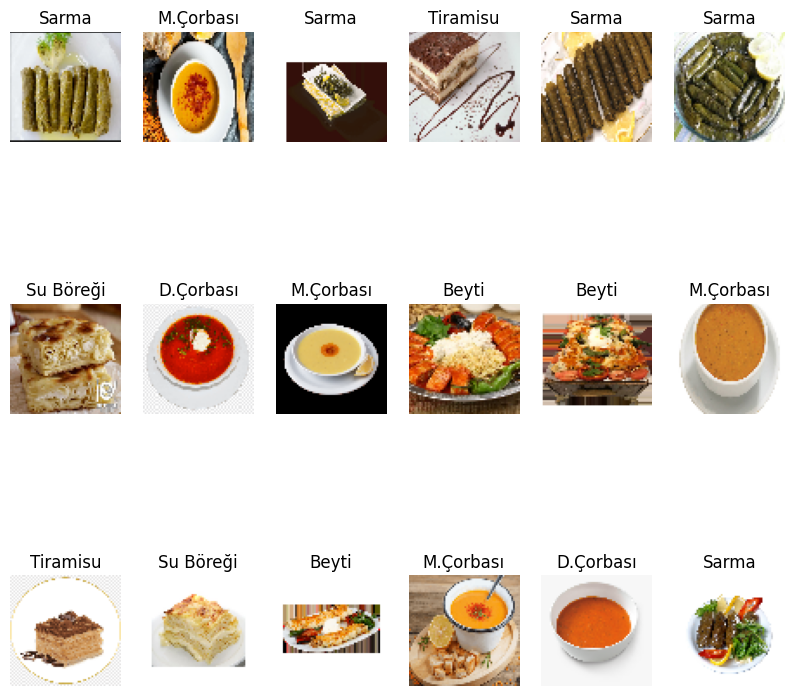

In [7]:
# Örnek görselleri görselleştir
class_names = ["Beyti", "D.Çorbası", "M.Çorbası", "Sarma", "Su Böreği", "Tiramisu"]
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(18):
        ax = plt.subplot(3, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [8]:
# Model mimarisi
model = tf.keras.Sequential(
    [
        # Data Augmentation
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),

        # Preprocessing
        tf.keras.layers.Rescaling(1./255),

        # Conv blokları
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # Classifier
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(6)
    ]
)

In [18]:
# Compile ve eğitim
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 502ms/step - accuracy: 0.8882 - loss: 0.2621 - val_accuracy: 0.7822 - val_loss: 0.6765
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 517ms/step - accuracy: 0.9161 - loss: 0.2300 - val_accuracy: 0.8713 - val_loss: 0.4826
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - accuracy: 0.9548 - loss: 0.1345 - val_accuracy: 0.8416 - val_loss: 0.5684
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 413ms/step - accuracy: 0.9118 - loss: 0.2242 - val_accuracy: 0.7030 - val_loss: 1.4127
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 454ms/step - accuracy: 0.9140 - loss: 0.2602 - val_accuracy: 0.8614 - val_loss: 0.6266
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 460ms/step - accuracy: 0.9290 - loss: 0.1969 - val_accuracy: 0.8812 - val_loss: 0.4332
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 364ms/step - accuracy: 0.9613 - loss: 0.1118 - val_accuracy: 0.6931 - val_loss: 1.5411
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 449ms/step - accuracy: 0.9204 - loss: 0.2498 - val_accu

In [19]:
# Test seti değerlendirme
model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.9109 - loss: 0.2791


[0.2791265845298767, 0.9108911156654358]

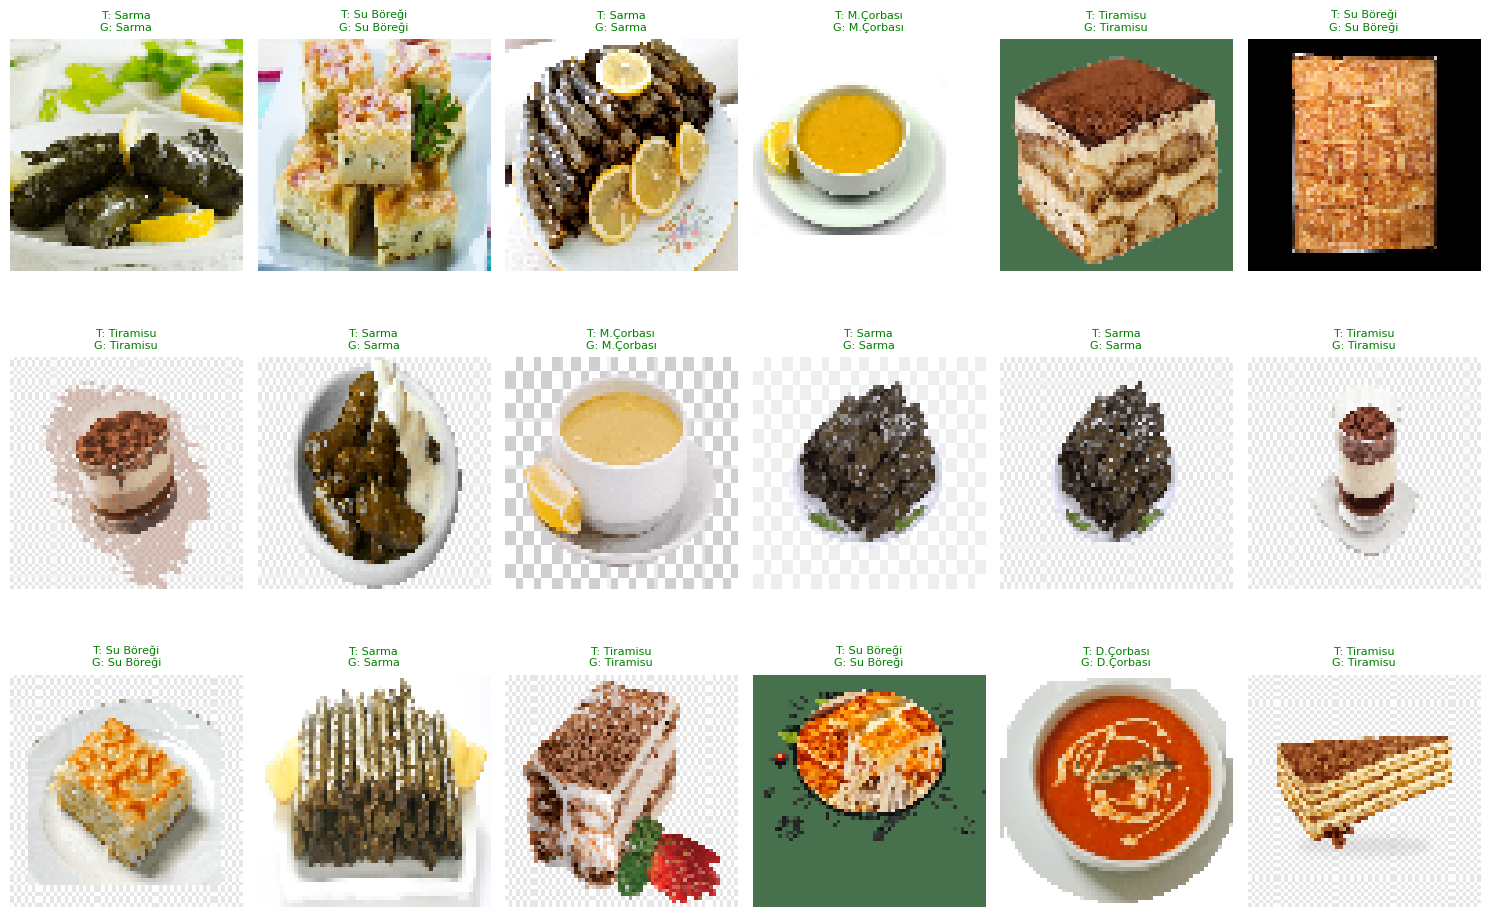

In [21]:
import numpy
from scipy.special import softmax

plt.figure(figsize=(15, 10))
for images, labels in test_ds.take(1):
    classifications = model(images)

for i in range(18):
    ax = plt.subplot(3, 6, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))

    probs = softmax(classifications[i])
    index = numpy.argmax(probs)
    confidence = probs[index]

    if confidence < 0.7:
        pred_label = "?"
    else:
        pred_label = class_names[index]

    real_label = class_names[labels[i]]
    color = "green" if pred_label == real_label else "red"

    plt.title(f"T: {pred_label}\nG: {real_label}", color=color, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# TFLite'a dönüştür ve kaydet
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpzl9mw45a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139128027912848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027915728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027915920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027916880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027917264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027918032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027917456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027918992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027909584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139128027919376: TensorSpec(shape=(), dtype=tf.resource, name=None)
